In [1]:
import pandas as pd

path = "/Users/roshanmoazed/Downloads/day.csv"

def load_data(path):
    return pd.read_csv(path) #your file path

In [2]:
df = load_data(path)
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [7]:
#error (~750) relative to mean (~4500) means ~17% error
#overfitting is low as gao between train and test RSME is small

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

df_clean = df.copy()

y = df_clean['cnt']

X = df_clean.drop(columns=['cnt', 'casual', 'registered', 'dteday', 'instant'], errors='ignore')

X['month_sin'] = np.sin(2 * np.pi * X['mnth'] / 12)
X['month_cos'] = np.cos(2 * np.pi * X['mnth'] / 12)
X = X.drop(columns=['mnth'])

X = pd.get_dummies(
    X,
    columns=['season', 'weekday', 'weathersit'],
    drop_first=False
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print(df_clean['cnt'].describe())
print("first 10 true:", y_test.iloc[:10].values)
print("first 10 pred:", test_preds[:10])

Train RMSE: 512.3160698661222
Test RMSE: 739.0518011021626
count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64
first 10 true: [6606 1550 3747 6041 7538 7264 1605 2209 7499 5743]
first 10 pred: [6527.24043595 1496.06531586 3231.65713454 5203.73513381 7793.27523804
 7185.45066742 1425.65242665 2057.62910858 7000.74653182 6522.30842293]


In [9]:
import pandas as pd

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

print(feat_imp.sort_values(ascending=False))

temp            0.368397
yr              0.301217
atemp           0.159751
hum             0.055216
season_4        0.035028
windspeed       0.019829
season_1        0.017936
month_sin       0.015219
weathersit_1    0.006357
month_cos       0.005287
weathersit_3    0.004203
workingday      0.003886
weathersit_2    0.002126
weekday_0       0.001925
weekday_6       0.001687
weekday_1       0.000480
season_2        0.000416
weekday_3       0.000260
weekday_4       0.000233
weekday_2       0.000208
weekday_5       0.000176
season_3        0.000164
holiday         0.000000
dtype: float64


In [11]:
baseline_pred = [y_train.mean()] * len(y_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 2022.1728092627525


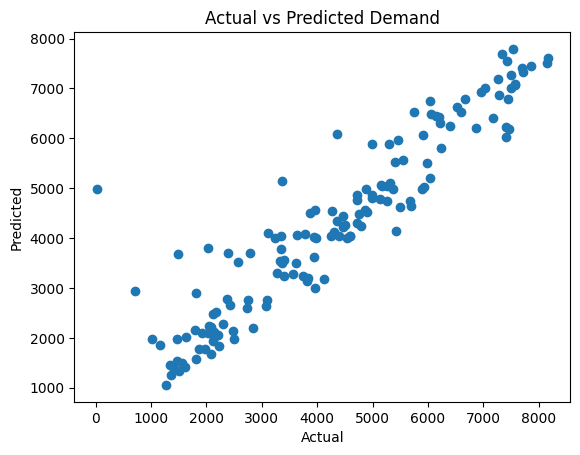

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, test_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Demand")
plt.show()

In [15]:
import numpy as np
import pandas as pd

BASE_PRICE = 5.0
ALPHA = 0.25 #how sensitive demand is to price, sampled with a bunch of different alphas, built a demand
#forecasting system with pricing optimization under multiple elasticity scenarios

def adjusted_demand(predicted_demand, price, base_price = BASE_PRICE, alpha = ALPHA):
    demand = predicted_demand *  (1 - alpha * (price-base_price))
    return max(demand,0) #demand can't go below 0

def revenue(predicted_demand, price, base_price=BASE_PRICE, alpha=ALPHA):
    demand = adjusted_demand(predicted_demand, price, base_price, alpha)
    return price * demand

In [17]:
example_demand = test_preds[0]
prices = np.arange(3.0, 8.1, 0.25)

results = []

for p in prices:
    adj_d = adjusted_demand(example_demand, p)
    rev = revenue(example_demand, p)
    results.append((p, adj_d, rev))

pricing_df = pd.DataFrame(results, columns=['price', 'adjusted_demand', 'revenue'])
print(pricing_df)

    price  adjusted_demand       revenue
0    3.00      9790.860654  29372.581962
1    3.25      9382.908127  30494.451412
2    3.50      8974.955599  31412.344598
3    3.75      8567.003072  32126.261521
4    4.00      8159.050545  32636.202180
5    4.25      7751.098018  32942.166575
6    4.50      7343.145490  33044.154707
7    4.75      6935.192963  32942.166575
8    5.00      6527.240436  32636.202180
9    5.25      6119.287909  32126.261521
10   5.50      5711.335381  31412.344598
11   5.75      5303.382854  30494.451412
12   6.00      4895.430327  29372.581962
13   6.25      4487.477800  28046.736248
14   6.50      4079.525272  26516.914271
15   6.75      3671.572745  24783.116030
16   7.00      3263.620218  22845.341526
17   7.25      2855.667691  20703.590758
18   7.50      2447.715163  18357.863726
19   7.75      2039.762636  15808.160431
20   8.00      1631.810109  13054.480872


In [19]:
best_row = pricing_df.loc[pricing_df['revenue'].idxmax()]
print("Best price:", best_row['price'])
print("Expected demand:", best_row['adjusted_demand'])
print("Expected revenue:", best_row['revenue'])

Best price: 4.5
Expected demand: 7343.145490443768
Expected revenue: 33044.15470699695


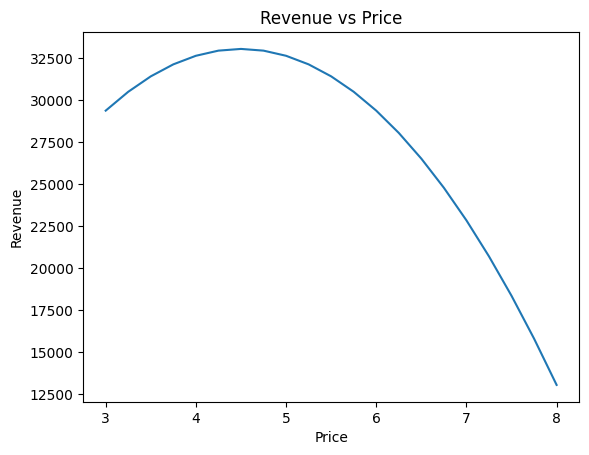

In [21]:
import matplotlib.pyplot as plt

plt.plot(pricing_df['price'], pricing_df['revenue'])
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title("Revenue vs Price")
plt.show()

In [29]:
def find_best_price(predicted_demand, price_min = 3.0, price_max = 8.0, step = 0.25,
                    base_price = BASE_PRICE, alpha  = ALPHA):
    prices = np.arange(price_min, price_max + step, step)
    best_price = None
    best_revenue = -np.inf
    best_demand = None

    for p in prices:
        adj_d = adjusted_demand(predicted_demand, p, base_price, alpha)
        rev = revenue(predicted_demand, p, base_price, alpha)

        if rev > best_revenue:
            best_price = p
            best_revenue = rev
            best_demand = adj_d

    return {
        "predicted_baseline_demand": float(predicted_demand),
        "optimal_price": float(best_price),
        "expected_adjusted_demand": float(best_demand),
        "expected_revenue": float(best_revenue)
    }

        

In [31]:
print(find_best_price(test_preds[0]))

{'predicted_baseline_demand': 6527.240435950016, 'optimal_price': 4.5, 'expected_adjusted_demand': 7343.145490443768, 'expected_revenue': 33044.15470699695}


In [33]:
#above is price optimization for one day, now want price optimization across many days

results = []

for i, pred in enumerate(test_preds):
    if i % 20 == 0:
        print(f"Processing {i}")
    res = find_best_price(pred)
    results.append(res)

pricing_results = pd.DataFrame(results)

print(pricing_results.head())

Processing 0
Processing 20
Processing 40
Processing 60
Processing 80
Processing 100
Processing 120
Processing 140
   predicted_baseline_demand  optimal_price  expected_adjusted_demand  \
0                6527.240436            4.5               7343.145490   
1                1496.065316            4.5               1683.073480   
2                3231.657135            4.5               3635.614276   
3                5203.735134            4.5               5854.202026   
4                7793.275238            4.5               8767.434643   

   expected_revenue  
0      33044.154707  
1       7573.830662  
2      16360.264244  
3      26343.909115  
4      39453.455893  


In [35]:
float(pricing_results['optimal_price'].mean())

4.5

In [37]:
baseline_revenue = BASE_PRICE * test_preds
pricing_results['baseline_revenue'] = baseline_revenue

pricing_results['revenue_gain'] = (
    pricing_results['expected_revenue'] - pricing_results['baseline_revenue']
)

print(pricing_results['revenue_gain'].mean())

267.69293766095325


In [43]:
total_baseline = pricing_results['baseline_revenue'].sum()
total_optimized = pricing_results['expected_revenue'].sum()

percent_increase = ((total_optimized - total_baseline) / total_baseline) * 100
print(percent_increase)

1.2499999999999971


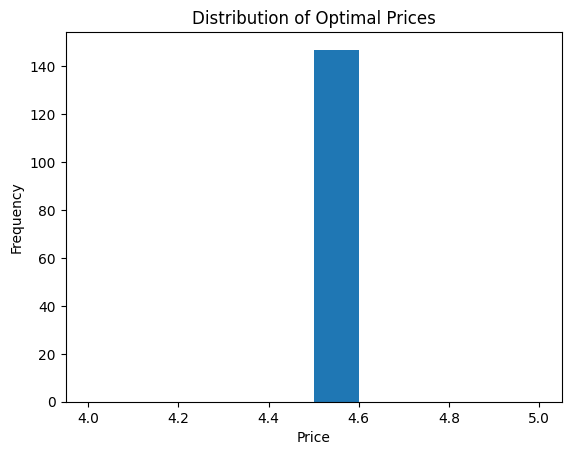

In [41]:
import matplotlib.pyplot as plt

plt.hist(pricing_results['optimal_price'], bins=10)
plt.title("Distribution of Optimal Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()